***Title: Classification Models Assignment***

***Name: Gedion Sang***

***ID: CS-DA03-26010***

***Date: 23/03/2026***

# Deep Learning

## Introduction
In this assignment, you will apply your understanding of Artificial Neural Networks and TensorFlow/Keras to build, train, evaluate, and document an image classification model using the MNIST dataset.

MNIST stands for Modified National Institute of Standards and Technology dataset. It is a benchmark dataset widely used in training and testing machine learning and deep learning models for handwritten digit recognition.


### 1. Import Libraries and Load the Data
Import the necessary libraries for data manipulation, visualization, and building the neural network. This includes `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for plotting, `tensorflow` and `keras` for building and training the model, and `sklearn.metrics` for evaluation


In [ ]:
## Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report


### Step 2: Load the Data
Load the MNIST dataset, which consists of handwritten digits. The dataset is split into training and testing sets.

In [ ]:

# Step 2: Load the Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()


### Step 3: Preprocess the Data
Normalize the pixel values of the images to a range of 0 to 1 by dividing by 255.0. This helps the neural network train more effectively. Also, one-hot encode the labels (`y_train` and `y_test`) for categorical cross-entropy loss.

In [ ]:

# Step 3: Preprocess the Data
X_train = X_train / 255.0  # Normalize pixel values to [0,1]
X_test = X_test / 255.0
y_train_cat = to_categorical(y_train, 10)  # One-hot encode labels
y_test_cat = to_categorical(y_test, 10)


### Visualize Sample Digits
This section displays a few sample handwritten digits from the training dataset along with their corresponding labels to give an idea of the data.

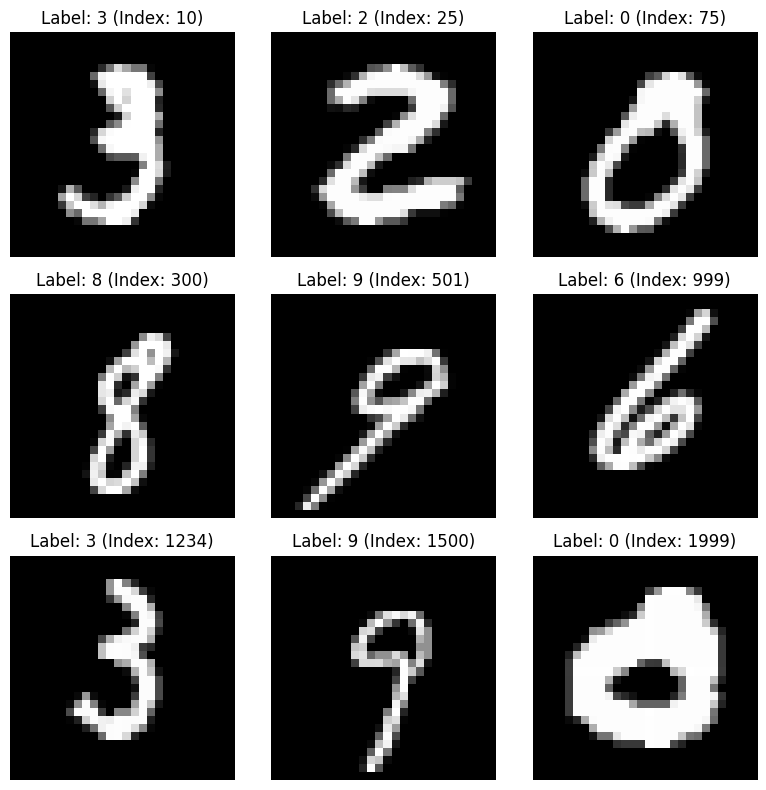

In [ ]:

# Plot some digits from dataset
selected_indices = [10, 25, 75, 300, 501, 999, 1234, 1500, 1999]  # Choose which image indices to display

plt.figure(figsize=(8, 8))

for i, idx in enumerate(selected_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]} (Index: {idx})")
    plt.axis('off')

plt.tight_layout()
plt.show()


### Step 4: Build the ANN Model
This code defines the architecture of the Artificial Neural Network (ANN) using Keras's Sequential API. The model consists of:
- A `Flatten` layer to convert the 2D image (28x28 pixels) into a 1D vector.
- Two `Dense` (fully connected) layers with `relu` activation for learning complex patterns.
- `Dropout` layers are included to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
- The final `Dense` layer has 10 units (for 10 digits) and a `softmax` activation function to output probabilities for each digit class.

In [ ]:

# Step 4: Build the ANN Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Step 5: Compile the Model
Compile the model by specifying the optimizer, loss function, and metrics.
- `optimizer='adam'`: An efficient stochastic gradient descent optimizer.
- `loss='categorical_crossentropy'`: Suitable for multi-class classification problems with one-hot encoded labels.
- `metrics=['accuracy']`: To monitor the accuracy during training and evaluation.

In [ ]:

# Step 5: Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


### Step 6: Train the Model
Train the ANN model using the training data (`X_train`, `y_train_cat`).
- `epochs=10`: The number of times the model will iterate over the entire training dataset.
- `batch_size=128`: The number of samples per gradient update.
- `validation_split=0.1`: 10% of the training data will be used for validation during training to monitor performance on unseen data.
- `verbose=1`: Displays a progress bar and metrics during training.

In [ ]:

# Step 6: Train the Model
history = model.fit(X_train, y_train_cat,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.1,
                    verbose=1)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8364 - loss: 0.5401 - val_accuracy: 0.9550 - val_loss: 0.1591
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9259 - loss: 0.2521 - val_accuracy: 0.9672 - val_loss: 0.1133
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9422 - loss: 0.1974 - val_accuracy: 0.9713 - val_loss: 0.0950
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9505 - loss: 0.1659 - val_accuracy: 0.9735 - val_loss: 0.0943
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9569 - loss: 0.1442 - val_accuracy: 0.9770 - val_loss: 0.0782
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9602 - loss: 0.1305 - val_accuracy: 0.9753 - val_loss: 0.0846
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9644 - loss: 0.1206 - val_accuracy: 0.9773 - val_loss: 0.0790
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9675 - loss: 0.1078 - val_accuracy: 0.

### Step 7: Evaluate on Test Set
Evaluate the trained model's performance on the unseen test dataset (`X_test`, `y_test_cat`) to assess its generalization capability. The output will show the test loss and test accuracy.

In [ ]:

# Step 7: Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.0778
Test Accuracy: 0.9777


### Step 8: Visualize Training History
This code plots the training and validation accuracy over the epochs. This visualization helps in understanding if the model is overfitting (validation accuracy much lower than training accuracy) or underfitting.

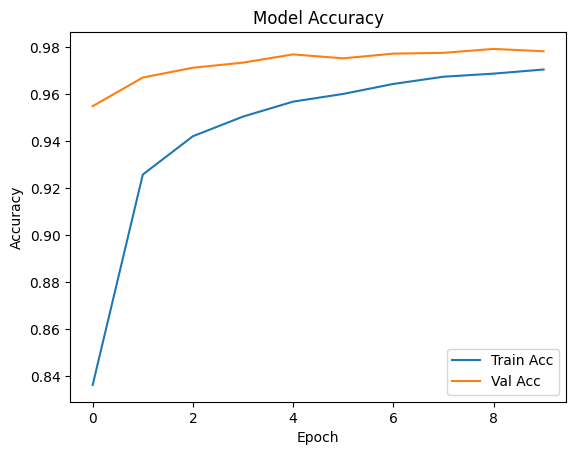

In [ ]:

# Step 8: Visualize Training History
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### Step 9: Confusion Matrix
Generate and visualize a confusion matrix to understand the performance of the classification model in more detail. Each cell `(i, j)` in the matrix represents the number of samples that were actually in class `i` but predicted to be in class `j`.
- `y_pred = model.predict(X_test)`: Predicts the class probabilities for the test set.
- `y_pred_classes = np.argmax(y_pred, axis=1)`: Converts the probability predictions to actual class labels.
- `confusion_matrix(y_test, y_pred_classes)`: Computes the confusion matrix.
- `sns.heatmap(...)`: Visualizes the confusion matrix with a heatmap.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


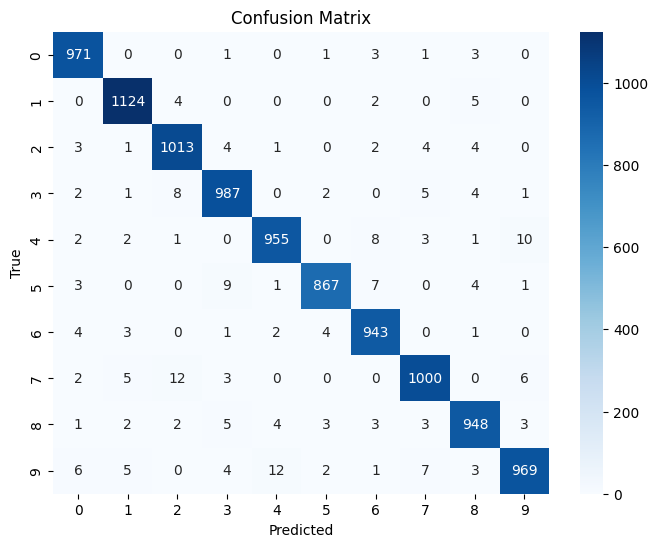

In [ ]:

# Step 9: Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### Step 10: Classification Report
Print a detailed classification report, which includes precision, recall, f1-score, and support for each class. This report provides a comprehensive overview of the model's performance on a per-class basis.

In [ ]:

# Step 10: Classification Report
print(classification_report(y_test, y_pred_classes))


              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.97      0.98       892
           6       0.97      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Step 11: Save and Reload the Model
Save the trained model to a file (`mnist_ann_model.h5`).
Load the model back from the file to demonstrate that it can be reloaded and used for evaluation without retraining. This is crucial for deployment scenarios.

In [ ]:

# Step 11: Save and Reload the Model
model.save("mnist_ann_model.h5")

from tensorflow.keras.models import load_model
reloaded_model = load_model("mnist_ann_model.h5")
reloaded_model.evaluate(X_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.0778


[0.07776033878326416, 0.9776999950408936]